# Chicago Crimes - Baseline & Modeling 

Input: `training_table.parquet` (output Notebook 05). Target: `risk_score` (0-100).

## 0. Setup, Palette, & Konfigurasi

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')
pd.set_option('display.width', 180); pd.set_option('display.max_columns', 60)

# Palette
BRAND_INDIGO='#3D2B9E'; BRAND_VIOLET='#7B3FE4'; BRAND_MAGENTA='#CE1C8E'; BRAND_PINK='#EC6DB4'; BRAND_LIGHT='#F7B4DA'
BRAND_COLORS=[BRAND_MAGENTA, BRAND_INDIGO, BRAND_VIOLET, BRAND_PINK, BRAND_LIGHT]
ACCENT=BRAND_MAGENTA; ACCENT2=BRAND_INDIGO
BRAND_CMAP=LinearSegmentedColormap.from_list('brand', ['#241663', BRAND_INDIGO, BRAND_VIOLET, BRAND_MAGENTA, BRAND_PINK, BRAND_LIGHT])
try:
    mpl.colormaps.register(BRAND_CMAP); mpl.colormaps.register(BRAND_CMAP.reversed())
except (ValueError, AttributeError):
    pass
plt.rcParams['axes.prop_cycle']=plt.cycler(color=BRAND_COLORS)
plt.rcParams['image.cmap']='brand'; plt.rcParams['figure.figsize']=(12,5); plt.rcParams['figure.dpi']=110
plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.25

# Konfigurasi
RANDOM_STATE=42
TARGET='risk_score'
OUT_DIR='/kaggle/working' if os.path.isdir('/kaggle/working') else '.'

# Fitur prediktor: KAUSAL (lagged)
# Kolom sekontemporer (n_crimes, arrest_rate, share_night, dst.) dan pembentuk label DIKECUALIKAN -> cegah leakage.
FEATURES=['glat','glon','gi','gj','year_idx','pmonth','pquarter','pmonth_sin','pmonth_cos',
          'lag_1','lag_3','lag_12','roll3_mean','roll6_mean','roll12_mean','cell_hist_mean','trend_3_12',
          'n_violent_lag1','arrest_rate_lag1','domestic_rate_lag1','neighbor_lag1_mean',
          'share_night_lag1','share_weekend_lag1']
LEAK_COLS=['harm','harm_temporal','harm_spatial','risk_raw','risk_score','risk_tier']
print('pandas', pd.__version__, '| numpy', np.__version__, '| n fitur', len(FEATURES), '| OUT_DIR', OUT_DIR)

pandas 2.3.3 | numpy 2.0.2 | n fitur 23 | OUT_DIR /kaggle/working


## 1. Load & Inspeksi training_table

Membaca output Notebook 05, memvalidasi kolom fitur/target, dan membuang bulan berjalan yang belum lengkap.

In [ ]:
CANDIDATE_PATHS=[
    '/kaggle/input/notebooks/fransiskaadin/05-pseudo-labeling-severity/training_table.parquet',
    '/kaggle/working/training_table.parquet',
    'training_table.parquet',
]

def load_training_table(paths):
    for p in paths:
        if os.path.exists(p):
            return pd.read_parquet(p), p
    raise FileNotFoundError('training_table tidak ditemukan pada kandidat path.')

df, src = load_training_table(CANDIDATE_PATHS)
df['period_dt']=pd.to_datetime(df['period_str']+'-01')
df=df.sort_values(['gi','gj','period_dt']).reset_index(drop=True)
print('Loaded:', src, '| shape:', df.shape)
print('Rentang periode:', df['period_str'].min(), '->', df['period_str'].max(), '| sel unik:', df[['gi','gj']].drop_duplicates().shape[0])

# Buang bulan berjalan yang belum lengkap (ditandai dengan is_partial_period)
n0=len(df)
df=df[df['is_partial_period']==0].copy()
print('Baris dibuang (is_partial_period==1):', n0-len(df), '| sisa:', len(df))

# Validasi kesiapan fitur & target
missing=[c for c in FEATURES if c not in df.columns]
print('Fitur hilang (harus []):', missing)
print('Target', TARGET, '-> NaN:', int(df[TARGET].isna().sum()), '| NaN fitur total:', int(df[FEATURES].isna().sum().sum()))
print('\nStatistik target risk_score:')
print(df[TARGET].describe().round(2).to_string())

Loaded: /kaggle/input/notebooks/fransiskaadin/05-pseudo-labeling-severity/training_table.parquet | shape: (226784, 42)
Rentang periode: 2001-01 -> 2026-04 | sel unik: 746
Baris dibuang (is_partial_period==1): 746 | sisa: 226038
Fitur hilang (harus []): []
Target risk_score -> NaN: 0 | NaN fitur total: 0

Statistik target risk_score:
count    226038.00
mean         78.03
std          15.47
min           0.00
25%          69.48
50%          82.16
75%          89.01
max         100.00


## 2. Feature Vector Assembly

Merangkai fitur menjadi satu matriks input dengan urutan kolom TETAP. Fungsi `assemble_features` dipakai identik untuk train, validasi, test, dan nanti saat serving (train/serving parity) sehingga tidak ada inkonsistensi representasi antar tahap.

In [3]:
def assemble_features(frame, features=FEATURES):
    # Susun matriks fitur dengan urutan kolom TETAP -> jaminan train/serving parity.
    # reindex mengunci set & urutan kolom; fillna(0) mengikuti konvensi HO1 (sel awal bernilai 0).
    X = frame.reindex(columns=features).astype('float32')
    return X.fillna(0.0)

X_all = assemble_features(df)
y_all = df[TARGET].astype('float32')
print('X_all:', X_all.shape, '| dtype float32 seragam:', bool((X_all.dtypes=='float32').all()),
      '| NaN:', int(X_all.isna().sum().sum()))
print('Urutan fitur terkunci sesuai FEATURES:', list(X_all.columns)==FEATURES)

X_all: (226038, 23) | dtype float32 seragam: True | NaN: 0
Urutan fitur terkunci sesuai FEATURES: True


## 3. Chronological Split

Data deret waktu tidak boleh dipisah acak. Split dilakukan berdasarkan waktu: train hingga 2021-12, validasi 2022-2023, test 2024 ke atas. Perbandingan string `period_str` (format YYYY-MM) setara urutan kronologis, sehingga tidak ada kebocoran periode antar split.

In [4]:
TRAIN_END='2021-12'   # train: <= 2021-12
VAL_END='2023-12'     # val: 2022-01..2023-12 ; test: > 2023-12

def split_chrono(frame, train_end, val_end):
    tr = frame[frame['period_str']<=train_end]
    va = frame[(frame['period_str']>train_end)&(frame['period_str']<=val_end)]
    te = frame[frame['period_str']>val_end]
    return tr, va, te

train_df, val_df, test_df = split_chrono(df, TRAIN_END, VAL_END)
for name, part in [('TRAIN',train_df),('VAL',val_df),('TEST',test_df)]:
    print(f'{name:5s} | baris {len(part):6d} | {part["period_str"].min()} -> {part["period_str"].max()}')

X_train, y_train = assemble_features(train_df), train_df[TARGET].astype('float32')
X_val,   y_val   = assemble_features(val_df),   val_df[TARGET].astype('float32')
X_test,  y_test  = assemble_features(test_df),  test_df[TARGET].astype('float32')
assert list(X_train.columns)==list(X_val.columns)==list(X_test.columns)==FEATURES
no_overlap = set(train_df['period_str']).isdisjoint(val_df['period_str']) and set(val_df['period_str']).isdisjoint(test_df['period_str'])
print('Shapes -> X_train', X_train.shape, '| X_val', X_val.shape, '| X_test', X_test.shape)
print('Tidak ada overlap periode antar split:', no_overlap)

TRAIN | baris 187992 | 2001-01 -> 2021-12
VAL   | baris  17904 | 2022-01 -> 2023-12
TEST  | baris  20142 | 2024-01 -> 2026-03
Shapes -> X_train (187992, 23) | X_val (17904, 23) | X_test (20142, 23)
Tidak ada overlap periode antar split: True


## 4. Baseline (tanpa training)

Tiga baseline kausal: (1) rata-rata global dari train, (2) rata-rata historis per sel, (3) persistence (nilai risk_score bulan sebelumnya).

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    yt = np.asarray(y_true, dtype='float64'); yp = np.asarray(y_pred, dtype='float64')
    return {'MAE': mean_absolute_error(yt, yp),
            'RMSE': mean_squared_error(yt, yp) ** 0.5,
            'R2': r2_score(yt, yp)}

# Baseline 1: rata-rata global (dari train)
global_mean = float(y_train.mean())

# Baseline 2: rata-rata historis per sel (dihitung dari train), fallback ke global_mean utk sel baru
cell_mean = train_df.groupby(['gi','gj'])[TARGET].mean()
def predict_cell_mean(frame):
    keys = pd.Series(list(zip(frame['gi'], frame['gj'])))
    return keys.map(cell_mean).fillna(global_mean).to_numpy()

# Baseline 3: persistence (risk_score bulan sebelumnya per sel; kausal, hanya lihat masa lalu)
persist = df.groupby(['gi','gj'])[TARGET].shift(1)

baselines_test = {
    'GlobalMean': np.full(len(y_test), global_mean),
    'CellMean': predict_cell_mean(test_df),
    'Persistence': persist.loc[test_df.index].fillna(global_mean).to_numpy(),
}
rows = []
for name, pred in baselines_test.items():
    m = regression_metrics(y_test, pred); m['model'] = name; rows.append(m)
baseline_res = pd.DataFrame(rows)[['model','MAE','RMSE','R2']].sort_values('MAE').reset_index(drop=True)
best_baseline = baseline_res.iloc[0]['model']
print(baseline_res.round(3).to_string(index=False))
print('Baseline terbaik (MAE):', best_baseline)

      model    MAE   RMSE     R2
Persistence  0.322  0.463  0.999
   CellMean  3.026  4.051  0.914
 GlobalMean 10.679 13.964 -0.022
Baseline terbaik (MAE): Persistence


Persistence (skor bulan lalu per sel) sangat kuat (MAE 0.322) karena `risk_score` mulus dan terautokorelasi tinggi antar bulan. 

## 5. Regression Model

In [6]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

candidates = {
    'Ridge': make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    'RandomForest': RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
    'HistGBR': HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08, max_depth=None, random_state=RANDOM_STATE),
}

val_rows = {}; fitted = {}
for name, model in candidates.items():
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_val), 0, 100)
    m = regression_metrics(y_val, pred); m['model'] = name
    val_rows[name] = m; fitted[name] = model

val_res = pd.DataFrame(val_rows.values())[['model','MAE','RMSE','R2']].sort_values('MAE').reset_index(drop=True)
best_name = val_res.iloc[0]['model']
best_model = fitted[best_name]
print(val_res.round(3).to_string(index=False))
print('Model terpilih (berdasar MAE validasi):', best_name)

       model   MAE  RMSE    R2
     HistGBR 0.946 1.331 0.991
RandomForest 1.023 1.484 0.988
       Ridge 5.359 7.071 0.738
Model terpilih (berdasar MAE validasi): HistGBR


## 6. Evaluation vs Baseline

In [7]:
# Evaluasi model terpilih pada test set
test_pred = np.clip(best_model.predict(X_test), 0, 100)
model_test_metrics = regression_metrics(y_test, test_pred); model_test_metrics['model'] = best_name

compare = pd.concat([baseline_res, pd.DataFrame([model_test_metrics])[['model','MAE','RMSE','R2']]],
                    ignore_index=True).sort_values('MAE').reset_index(drop=True)
base_mae = baseline_res.loc[baseline_res['model']==best_baseline, 'MAE'].iloc[0]
improve = 100*(base_mae - model_test_metrics['MAE'])/base_mae
print(compare.round(3).to_string(index=False))
print(f'\nPeningkatan MAE {best_name} vs baseline terbaik ({best_baseline}): {improve:.1f} persen')

      model    MAE   RMSE     R2
Persistence  0.322  0.463  0.999
    HistGBR  1.031  1.398  0.990
   CellMean  3.026  4.051  0.914
 GlobalMean 10.679 13.964 -0.022

Peningkatan MAE HistGBR vs baseline terbaik (Persistence): -219.9 persen


Model v1 (HistGBR, MAE 1.031) justru KALAH dari Persistence (0.322). Sebabnya: fitur v1 belum memuat nilai `risk_score` masa lalu, padahal itu sinyal terkuat. Temuan ini memotivasi penambahan fitur lag-risk di bawah.

In [8]:
from sklearn.inspection import permutation_importance

# permutation importance: berlaku utk semua jenis model (termasuk HistGBR & pipeline).
# Disubsample utk efisiensi; skor = penurunan MAE saat fitur diacak.
n_imp = min(20000, len(X_val))
perm = permutation_importance(best_model, X_val.iloc[:n_imp], y_val.iloc[:n_imp],
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
                              scoring='neg_mean_absolute_error')
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
print('Top 10 fitur paling berpengaruh:')
print(imp.head(10).round(4).to_string())

Top 10 fitur paling berpengaruh:
neighbor_lag1_mean    7.7396
glon                  2.9434
glat                  2.3250
cell_hist_mean        0.7711
roll6_mean            0.4774
roll3_mean            0.1110
roll12_mean           0.1031
pmonth_sin            0.0306
lag_1                 0.0247
lag_3                 0.0124


`neighbor_lag1_mean` dan koordinat spasial paling berpengaruh; model bertumpu pada konteks tetangga & lokasi, bukan riwayat sel itu sendiri, konsisten dengan lemahnya v1 terhadap Persistence.

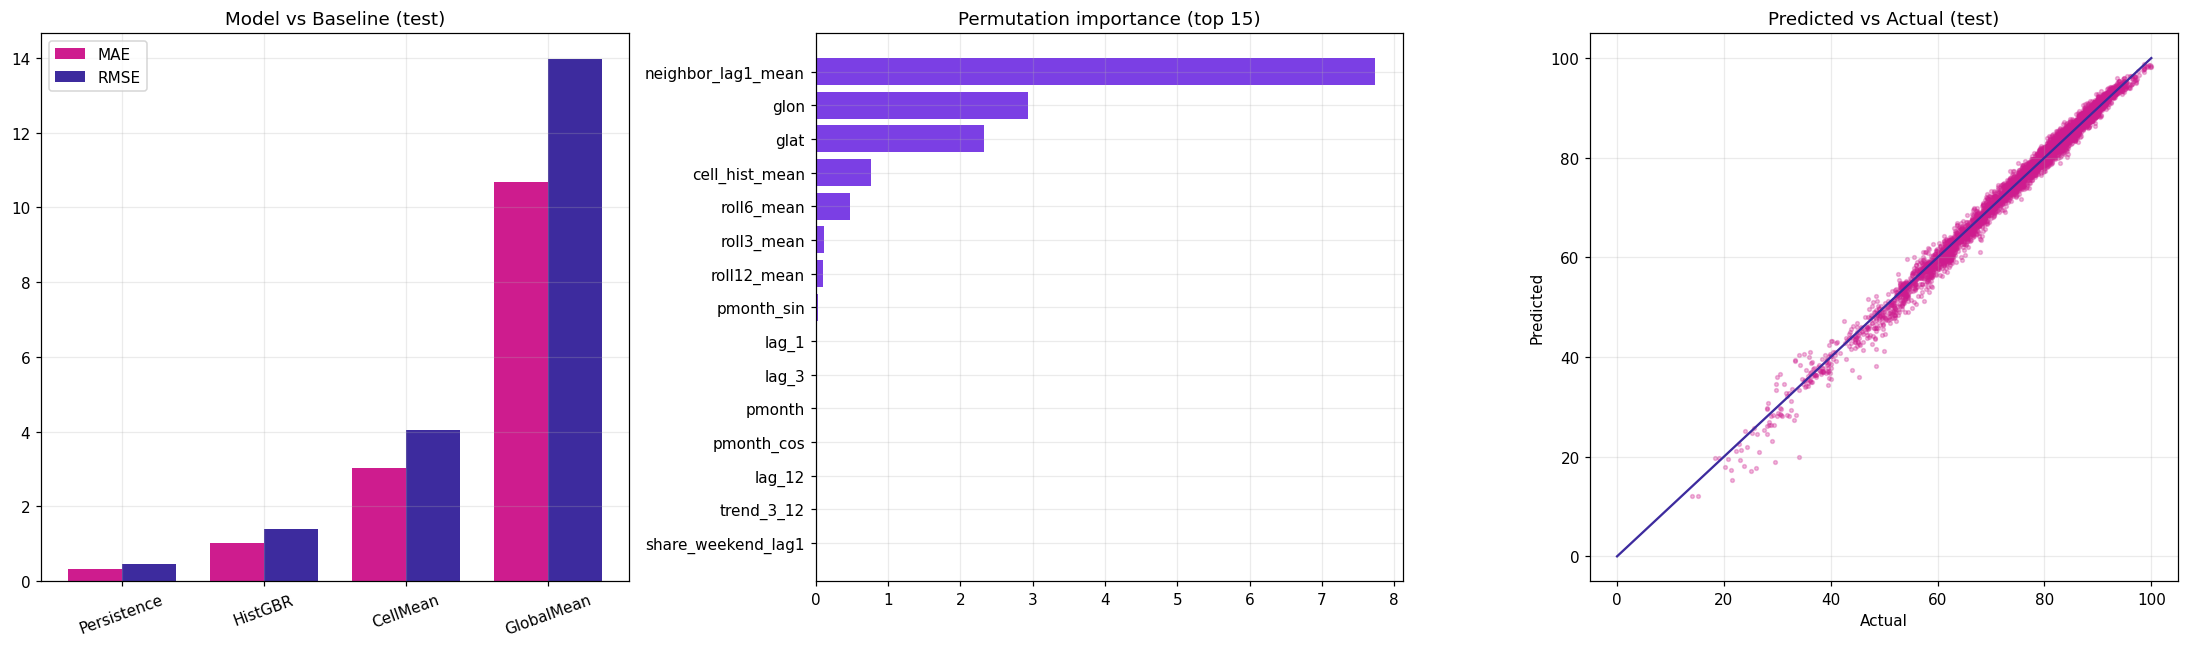

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Perbandingan MAE & RMSE: model vs baseline
x = np.arange(len(compare)); w = 0.38
axes[0].bar(x-w/2, compare['MAE'], w, label='MAE', color=BRAND_MAGENTA)
axes[0].bar(x+w/2, compare['RMSE'], w, label='RMSE', color=BRAND_INDIGO)
axes[0].set_xticks(x); axes[0].set_xticklabels(compare['model'], rotation=20)
axes[0].set_title('Model vs Baseline (test)'); axes[0].legend()

# (b) Feature importance (top 15)
top = imp.head(15).iloc[::-1]
axes[1].barh(top.index, top.values, color=BRAND_VIOLET)
axes[1].set_title('Permutation importance (top 15)')

# (c) Predicted vs actual (subsample utk kejelasan)
smp = np.random.default_rng(RANDOM_STATE).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
axes[2].scatter(np.asarray(y_test)[smp], test_pred[smp], s=6, alpha=0.3, color=BRAND_MAGENTA)
axes[2].plot([0,100],[0,100], color=BRAND_INDIGO, lw=1.5)
axes[2].set_xlabel('Actual'); axes[2].set_ylabel('Predicted'); axes[2].set_title('Predicted vs Actual (test)')

fig.tight_layout(); plt.show()

### Fitur Lag-Risk 

baseline **persistence** (tebakan = risk bulan lalu) sangat kuat karena `risk_score` sangat terautokorelasi antar-waktu. Model v1 kalah karena TIDAK punya lag dari label itu sendiri; fitur lag-nya hanya lag aktivitas kejahatan.

Solusi: tambahkan `risk_lag_1/3/12` yaitu nilai `risk_score` bulan-bulan sebelumnya per sel, karena saat memprediksi bulan t, nilai risk pada t-1/t-3/t-12 memang sudah diketahui. Bangun ulang matriks fitur (urutan tetap terkunci) lalu latih ulang -> model v2.

In [10]:
# Bangun fitur lag dari label risk_score (kausal: hanya melihat masa lalu per sel)
RISK_LAGS = [1, 3, 12]
for L in RISK_LAGS:
    df[f'risk_lag_{L}'] = df.groupby(['gi','gj'])[TARGET].shift(L)
RISK_LAG_COLS = [f'risk_lag_{L}' for L in RISK_LAGS]
df[RISK_LAG_COLS] = df[RISK_LAG_COLS].fillna(global_mean)  # sel/bulan awal tanpa histori -> prior global (dari train)

FEATURES_EXT = FEATURES + RISK_LAG_COLS

# Re-split agar kolom baru ikut, lalu rakit ulang matriks fitur dengan urutan terkunci
train_df, val_df, test_df = split_chrono(df, TRAIN_END, VAL_END)
Xtr_e = assemble_features(train_df, FEATURES_EXT)
Xva_e = assemble_features(val_df,   FEATURES_EXT)
Xte_e = assemble_features(test_df,  FEATURES_EXT)
y_train = train_df[TARGET].astype('float32'); y_val = val_df[TARGET].astype('float32'); y_test = test_df[TARGET].astype('float32')
print('FEATURES_EXT:', len(FEATURES_EXT), '| X_train_ext:', Xtr_e.shape, '| NaN:', int(Xtr_e.isna().sum().sum()))
print('Kolom tambahan:', RISK_LAG_COLS)

FEATURES_EXT: 26 | X_train_ext: (187992, 26) | NaN: 0
Kolom tambahan: ['risk_lag_1', 'risk_lag_3', 'risk_lag_12']


In [11]:
# Latih ulang kandidat pada fitur diperluas, pilih terbaik berdasar MAE validasi -> model v2
candidates_ext = {
    'Ridge': make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    'RandomForest': RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
    'HistGBR': HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08, random_state=RANDOM_STATE),
}
val_rows_e = {}; fitted_e = {}
for name, model in candidates_ext.items():
    model.fit(Xtr_e, y_train)
    pred = np.clip(model.predict(Xva_e), 0, 100)
    m = regression_metrics(y_val, pred); m['model'] = name
    val_rows_e[name] = m; fitted_e[name] = model
val_res_ext = pd.DataFrame(val_rows_e.values())[['model','MAE','RMSE','R2']].sort_values('MAE').reset_index(drop=True)
best_name_ext = val_res_ext.iloc[0]['model']; best_model_ext = fitted_e[best_name_ext]
print(val_res_ext.round(3).to_string(index=False))
print('\nModel terpilih (dengan lag-risk):', best_name_ext)

       model   MAE  RMSE    R2
RandomForest 0.313 0.475 0.999
     HistGBR 0.329 0.531 0.999
       Ridge 0.377 0.535 0.999

Model terpilih (dengan lag-risk): RandomForest


Setelah menambahkan fitur lag-risk, RandomForest turun ke MAE 0.313 di validasi (dari ~1.0 pada v1), menutup celah terhadap Persistence.

### Evaluasi Kasus Sulit & Metrik Peringkat

MAE global menyesatkan di sini: karena target sangat mulus, semua metode terlihat bagus. Maka kita evaluasi dua hal yang lebih bermakna:

1. **Metrik peringkat** - `risk_score` dipakai untuk MEMERINGKAT area berisiko, jadi korelasi peringkat (Spearman) dan akurasi klasifikasi tier lebih mencerminkan kegunaan nyata daripada error absolut.
2. **Kasus sulit** - subset di mana persistence LEMAH: (A) bulan dengan perubahan besar dari bulan sebelumnya, dan (B) sel dengan volatilitas historis tinggi (std risk_score per sel di kuartil teratas). Grid Chicago bersifat tetap sehingga tidak ada "sel baru"; sel paling fluktuatif inilah yang paling menantang persistence. Di sinilah nilai tambah ML sesungguhnya terlihat.

In [12]:
# Evaluasi model v2 di test, bandingkan dengan seluruh baseline & model v1
test_pred_ext = np.clip(best_model_ext.predict(Xte_e), 0, 100)
m_ext = regression_metrics(y_test, test_pred_ext); m_ext['model'] = best_name_ext + ' (+lag-risk)'

compare_ext = pd.concat([
    compare[['model','MAE','RMSE','R2']],
    pd.DataFrame([m_ext])[['model','MAE','RMSE','R2']],
], ignore_index=True).drop_duplicates('model').sort_values('MAE').reset_index(drop=True)
print(compare_ext.round(3).to_string(index=False))

persist_mae = baseline_res.loc[baseline_res['model']=='Persistence','MAE'].iloc[0]
gain = 100*(persist_mae - m_ext['MAE'])/persist_mae
print(f'\nMAE model v2 (+lag-risk) vs Persistence: {gain:.1f} persen')

                   model    MAE   RMSE     R2
RandomForest (+lag-risk)  0.278  0.430  0.999
             Persistence  0.322  0.463  0.999
                 HistGBR  1.031  1.398  0.990
                CellMean  3.026  4.051  0.914
              GlobalMean 10.679 13.964 -0.022

MAE model v2 (+lag-risk) vs Persistence: 13.9 persen


Model v2 (RandomForest + lag-risk) MAE 0.278 mengalahkan Persistence (0.322) sebesar +13.9%. Perbaikan murni berasal dari memasukkan `risk_score` historis sebagai fitur.

In [13]:
# (1) Metrik peringkat: Spearman (rank correlation) + akurasi tier
def spearman_corr(a, b):
    ra = pd.Series(np.asarray(a, 'float64')).rank().to_numpy()
    rb = pd.Series(np.asarray(b, 'float64')).rank().to_numpy()
    return float(np.corrcoef(ra, rb)[0, 1])

TIER_BINS = [-0.01, 50, 80, 95, 100.01]; TIER_LABELS = ['LOW','MEDIUM','HIGH','VERY HIGH']
def to_tier(v): return pd.cut(np.asarray(v), bins=TIER_BINS, labels=TIER_LABELS)

sp = spearman_corr(y_test, test_pred_ext)
tier_acc = float((to_tier(y_test) == to_tier(test_pred_ext)).mean())
print(f'Spearman (peringkat) : {sp:.4f}')
print(f'Akurasi tier         : {tier_acc:.4f}')

# (2) Kasus sulit: subset di mana persistence lemah
persist_test = df.groupby(['gi','gj'])[TARGET].shift(1).loc[test_df.index].fillna(global_mean).to_numpy()
yte = np.asarray(y_test)

# (A) Bulan dengan perubahan besar dari bulan sebelumnya (top 25% |delta|)
change = np.abs(yte - persist_test); thr = np.quantile(change, 0.75); hard = change >= thr

# (B) Sel volatilitas tinggi: std risk_score per sel (dihitung dari train) di kuartil teratas.
# Grid Chicago bersifat tetap (semua sel ada sejak 2001) sehingga tidak ada "sel baru";
# subset yang menantang persistence adalah sel yang historis-nya paling fluktuatif.
cell_vol = train_df.groupby(['gi','gj'])[TARGET].std()
vol_map = pd.Series(list(zip(test_df['gi'], test_df['gj']))).map(cell_vol).fillna(0).to_numpy()
highvol = vol_map >= cell_vol.quantile(0.75)

def subset_mae(mask):
    return {'n': int(mask.sum()),
            'MAE_model': regression_metrics(yte[mask], test_pred_ext[mask])['MAE'],
            'MAE_persistence': regression_metrics(yte[mask], persist_test[mask])['MAE']}
hard_tbl = pd.DataFrame([
    {'subset': 'Semua test', **subset_mae(np.ones(len(yte), bool))},
    {'subset': 'Perubahan besar (top 25%)', **subset_mae(hard)},
    {'subset': 'Sel volatilitas tinggi', **subset_mae(highvol)},
])
print('\n'+hard_tbl.round(3).to_string(index=False))

Spearman (peringkat) : 0.9996
Akurasi tier         : 0.9888

                   subset     n  MAE_model  MAE_persistence
               Semua test 20142      0.278            0.322
Perubahan besar (top 25%)  5036      0.539            0.703
   Sel volatilitas tinggi  5049      0.334            0.371


Untuk tujuan MEMERINGKAT area berisiko, model unggul (Spearman 0.9996, akurasi tier 0.9888). Pada kasus sulit (perubahan besar & sel volatilitas tinggi) model tetap mengungguli Persistence, di sinilah nilai tambah ML terlihat.

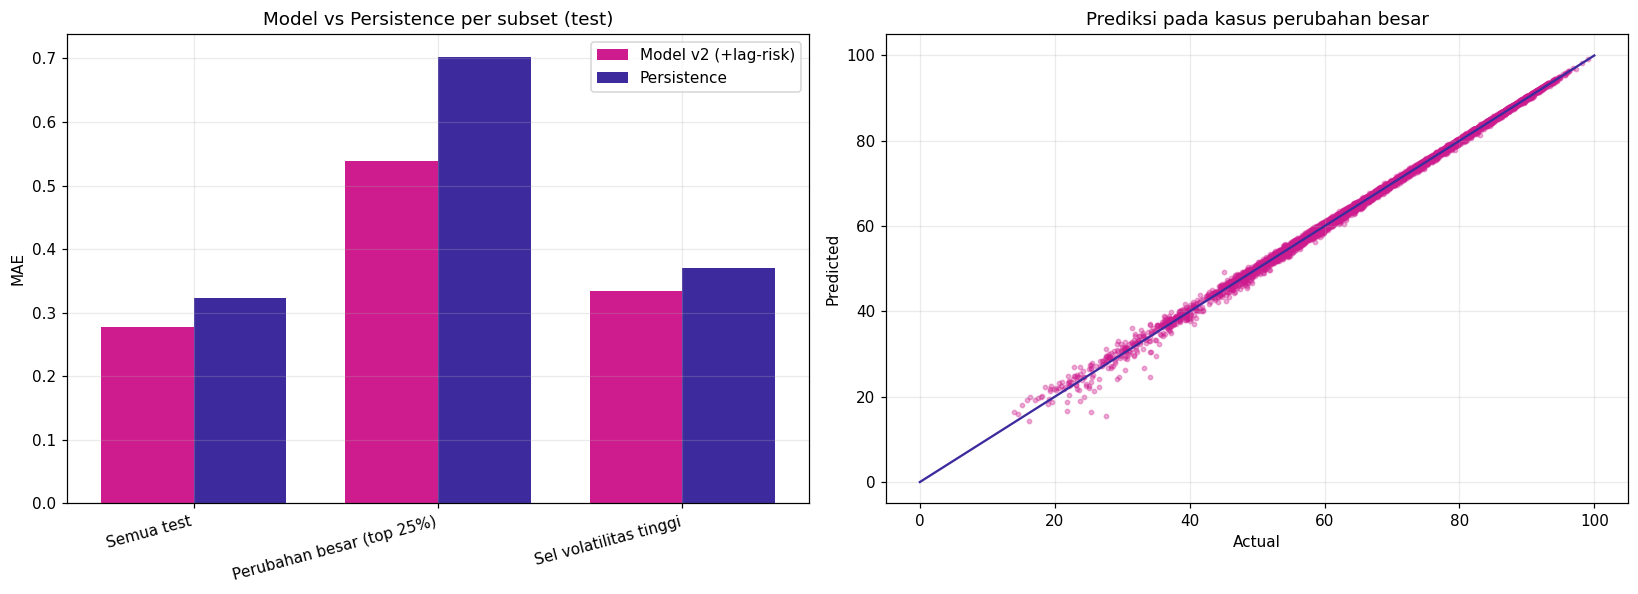

In [14]:
# Visualisasi: (a) model vs persistence per subset, (b) prediksi pada kasus perubahan besar
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
xs = np.arange(len(hard_tbl)); w = 0.38
axes[0].bar(xs - w/2, hard_tbl['MAE_model'], w, label='Model v2 (+lag-risk)', color=BRAND_MAGENTA)
axes[0].bar(xs + w/2, hard_tbl['MAE_persistence'], w, label='Persistence', color=BRAND_INDIGO)
axes[0].set_xticks(xs); axes[0].set_xticklabels(hard_tbl['subset'], rotation=15, ha='right')
axes[0].set_ylabel('MAE'); axes[0].set_title('Model vs Persistence per subset (test)'); axes[0].legend()

axes[1].scatter(yte[hard], test_pred_ext[hard], s=8, alpha=0.35, color=BRAND_MAGENTA)
axes[1].plot([0, 100], [0, 100], color=BRAND_INDIGO, lw=1.5)
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted'); axes[1].set_title('Prediksi pada kasus perubahan besar')
plt.tight_layout(); plt.show()

In [15]:
# Simpan artefak model v2 (dipakai sebagai kandidat unggulan utk Notebook 07)
import joblib
model_v2_path = os.path.join(OUT_DIR, 'model_v2_lagrisk.joblib')
joblib.dump(best_model_ext, model_v2_path)
meta_ext = {
    'features': FEATURES_EXT,
    'risk_lag_cols': RISK_LAG_COLS,
    'target': TARGET,
    'best_model': best_name_ext,
    'train_end': TRAIN_END, 'val_end': VAL_END,
    'test_metrics': {k: float(v) for k, v in m_ext.items() if k != 'model'},
    'ranking': {'spearman': float(sp), 'tier_accuracy': float(tier_acc)},
}
with open(os.path.join(OUT_DIR, 'feature_list_ext.json'), 'w') as f:
    json.dump(meta_ext, f, indent=2)
hard_tbl.to_csv(os.path.join(OUT_DIR, 'hardcase_metrics.csv'), index=False)
print('Artefak v2 tersimpan di', OUT_DIR)
print(' -', os.path.basename(model_v2_path))
print(' - feature_list_ext.json')
print(' - hardcase_metrics.csv')

Artefak v2 tersimpan di /kaggle/working
 - model_v2_lagrisk.joblib
 - feature_list_ext.json
 - hardcase_metrics.csv


## 7. Simpan Artefak

Menyimpan model terpilih, daftar fitur + metadata, dan tabel metrik ke `OUT_DIR`.

In [16]:
import joblib

model_path = os.path.join(OUT_DIR, 'model_v1.joblib')
joblib.dump(best_model, model_path)

meta = {
    'features': FEATURES,
    'target': TARGET,
    'best_model': best_name,
    'train_end': TRAIN_END,
    'val_end': VAL_END,
    'test_metrics': {k: float(v) for k, v in model_test_metrics.items() if k != 'model'},
    'best_baseline': best_baseline,
}
with open(os.path.join(OUT_DIR, 'feature_list.json'), 'w') as f:
    json.dump(meta, f, indent=2)
compare.to_csv(os.path.join(OUT_DIR, 'baseline_vs_model_metrics.csv'), index=False)
print('Artefak tersimpan di', OUT_DIR)
print(' -', os.path.basename(model_path))
print(' - feature_list.json')
print(' - baseline_vs_model_metrics.csv')

Artefak tersimpan di /kaggle/working
 - model_v1.joblib
 - feature_list.json
 - baseline_vs_model_metrics.csv
